In [ ]:
import { chatWithQwen } from "../services/aiService";

// Example Usage
const response = await chatWithQwen("Hello");
console.log(response);import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
pd.set_option('m1ax_columns',200)

In [2]:
df=pd.read_csv('/kaggle/input/leetcode-all-problems-dataset/leetcode_problem.csv')

In [3]:
df

,Unnamed: 0,id,title,description,is_premium,difficulty,solution_link,acceptance_rate,frequency,url,discuss_count,accepted,submissions,companies,related_topics,likes,dislikes,rating,asked_by_faang,similar_questions
0,0,1,Two Sum,Given an array of integers `nums` and an integ...,0,Easy,/articles/two-sum,46.7,100.0,https://leetcode.com/problems/two-sum,999,4.1M,8.7M,"Amazon,Google,Apple,Adobe,Microsoft,Bloomberg,...","Array,Hash Table",20217,712,97,1,"[3Sum, /problems/3sum/, Medium], [4Sum, /probl..."
1,1,2,Add Two Numbers,You are given two non-empty linked lists repre...,0,Medium,/articles/add-two-numbers,35.7,93.1,https://leetcode.com/problems/add-two-numbers,999,1.9M,5.2M,"Bloomberg,Microsoft,Amazon,Google,Facebook,App...","Linked List,Math,Recursion",11350,2704,81,1,"[Multiply Strings, /problems/multiply-strings/..."
2,2,3,Longest Substring Without Repeating Characters,"Given a string `s`, find the length of the lon...",0,Medium,/articles/longest-substring-without-repeating-...,31.5,90.9,https://leetcode.com/problems/longest-substrin...,999,2.1M,6.7M,"Amazon,Bloomberg,Microsoft,Facebook,Apple,Adob...","Hash Table,Two Pointers,String,Sliding Window",13810,714,95,1,[Longest Substring with At Most Two Distinct C...
3,3,4,Median of Two Sorted Arrays,Given two sorted arrays `nums1` and `nums2` of...,0,Hard,/articles/median-of-two-sorted-arrays,31.4,86.2,https://leetcode.com/problems/median-of-two-so...,999,904.7K,2.9M,"Amazon,Goldman Sachs,Facebook,Microsoft,Apple,...","Array,Binary Search,Divide and Conquer",9665,1486,87,1,NaN
4,4,5,Longest Palindromic Substring,"Given a string `s`, return the longest palindr...",0,Medium,/articles/longest-palindromic-substring,30.6,84.7,https://leetcode.com/problems/longest-palindro...,999,1.3M,4.1M,"Amazon,Microsoft,Wayfair,Facebook,Adobe,eBay,G...","String,Dynamic Programming",10271,670,94,1,"[Shortest Palindrome, /problems/shortest-palin..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,1820,1821,Find Customers With Positive Revenue this Year,SQL Schema,1,Easy,NaN,88.9,0.0,https://leetcode.com/problems/find-customers-w...,15,305,343,Google,NaN,2,2,50,1,NaN
1821,1821,1822,Sign of the Product of an Array,There is a function `signFunc(x)` that returns...,0,Easy,NaN,67.8,0.0,https://leetcode.com/problems/sign-of-the-prod...,104,7.9K,11.7K,Microsoft,Math,37,4,90,0,NaN
1822,1822,1823,Find the Winner of the Circular Game,There are `n` friends that are playing a game....,0,Medium,NaN,71.8,0.0,https://leetcode.com/problems/find-the-winner-...,135,6.8K,9.5K,Bloomberg,Array,81,4,95,0,NaN
1823,1823,1824,Minimum Sideway Jumps,There is a 3 lane road of length `n` that cons...,0,Medium,NaN,47.2,0.0,https://leetcode.com/problems/minimum-sideway-...,134,5K,10.7K,Pony.ai,"Dynamic Programming,Breadth-first Search",147,8,95,0,"[Frog Jump, /problems/frog-jump/, Hard]"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1825 non-null   int64  
 1   id                 1825 non-null   int64  
 2   title              1825 non-null   object 
 3   description        1825 non-null   object 
 4   is_premium         1825 non-null   int64  
 5   difficulty         1825 non-null   object 
 6   solution_link      987 non-null    object 
 7   acceptance_rate    1825 non-null   float64
 8   frequency          1825 non-null   float64
 9   url                1825 non-null   object 
 10  discuss_count      1825 non-null   int64  
 11  accepted           1825 non-null   object 
 12  submissions        1825 non-null   object 
 13  companies          1749 non-null   object 
 14  related_topics     1571 non-null   object 
 15  likes              1825 non-null   int64  
 16  dislikes           1825 

In [5]:
df['companies'].unique()

array(['Amazon,Google,Apple,Adobe,Microsoft,Bloomberg,Facebook,Oracle,Uber,Expedia,Twitter,Nagarro,SAP,Yahoo,Cisco,Qualcomm,tcs,Goldman Sachs,Yandex,ServiceNow',
       'Bloomberg,Microsoft,Amazon,Google,Facebook,Apple,Adobe,Paypal,Coupang,Oracle,Uber,VMware,Yahoo',
       'Amazon,Bloomberg,Microsoft,Facebook,Apple,Adobe,eBay,Goldman Sachs,Google,Alation,VMware,Oracle,ByteDance,Yahoo,Uber,SAP,Salesforce,Coupang,Splunk,Spotify',
       'Amazon,Goldman Sachs,Facebook,Microsoft,Apple,Adobe,Google,Bloomberg,Zillow,Uber,Flipkart,Paypal',
       'Amazon,Microsoft,Wayfair,Facebook,Adobe,eBay,Google,Oracle,Goldman Sachs,Yandex,Qualcomm',
       'Microsoft',
       'Amazon,Google,Apple,Facebook,Bloomberg,American Express,Microsoft,Adobe,Uber',
       'Facebook,Amazon,Microsoft,Google,Goldman Sachs,Apple,Adobe,Bloomberg,Intel',
       'Microsoft,Adobe,Bloomberg,Facebook,Google,Yahoo',
       'Facebook,Amazon,Microsoft,Google,Adobe,Coursera,Apple',
       'Amazon,Google,Microsoft,Facebook,Goldman

In [6]:
df=df.drop(['Unnamed: 0'],axis=1)

In [7]:
df.duplicated().sum()

0

In [8]:
new_df=df

In [9]:
new_df=new_df.drop(['description','solution_link','url','related_topics','similar_questions','companies'],axis=1)

In [10]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1825 non-null   int64  
 1   title            1825 non-null   object 
 2   is_premium       1825 non-null   int64  
 3   difficulty       1825 non-null   object 
 4   acceptance_rate  1825 non-null   float64
 5   frequency        1825 non-null   float64
 6   discuss_count    1825 non-null   int64  
 7   accepted         1825 non-null   object 
 8   submissions      1825 non-null   object 
 9   likes            1825 non-null   int64  
 10  dislikes         1825 non-null   int64  
 11  rating           1825 non-null   int64  
 12  asked_by_faang   1825 non-null   int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 185.5+ KB


In [11]:
new_df.isnull().sum()

id                 0
title              0
is_premium         0
difficulty         0
acceptance_rate    0
frequency          0
discuss_count      0
accepted           0
submissions        0
likes              0
dislikes           0
rating             0
asked_by_faang     0
dtype: int64

In [12]:
new_df.head()

,id,title,is_premium,difficulty,acceptance_rate,frequency,discuss_count,accepted,submissions,likes,dislikes,rating,asked_by_faang
0,1,Two Sum,0,Easy,46.7,100.0,999,4.1M,8.7M,20217,712,97,1
1,2,Add Two Numbers,0,Medium,35.7,93.1,999,1.9M,5.2M,11350,2704,81,1
2,3,Longest Substring Without Repeating Characters,0,Medium,31.5,90.9,999,2.1M,6.7M,13810,714,95,1
3,4,Median of Two Sorted Arrays,0,Hard,31.4,86.2,999,904.7K,2.9M,9665,1486,87,1
4,5,Longest Palindromic Substring,0,Medium,30.6,84.7,999,1.3M,4.1M,10271,670,94,1


In [13]:
new_df

,id,title,is_premium,difficulty,acceptance_rate,frequency,discuss_count,accepted,submissions,likes,dislikes,rating,asked_by_faang
0,1,Two Sum,0,Easy,46.7,100.0,999,4.1M,8.7M,20217,712,97,1
1,2,Add Two Numbers,0,Medium,35.7,93.1,999,1.9M,5.2M,11350,2704,81,1
2,3,Longest Substring Without Repeating Characters,0,Medium,31.5,90.9,999,2.1M,6.7M,13810,714,95,1
3,4,Median of Two Sorted Arrays,0,Hard,31.4,86.2,999,904.7K,2.9M,9665,1486,87,1
4,5,Longest Palindromic Substring,0,Medium,30.6,84.7,999,1.3M,4.1M,10271,670,94,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,1821,Find Customers With Positive Revenue this Year,1,Easy,88.9,0.0,15,305,343,2,2,50,1
1821,1822,Sign of the Product of an Array,0,Easy,67.8,0.0,104,7.9K,11.7K,37,4,90,0
1822,1823,Find the Winner of the Circular Game,0,Medium,71.8,0.0,135,6.8K,9.5K,81,4,95,0
1823,1824,Minimum Sideway Jumps,0,Medium,47.2,0.0,134,5K,10.7K,147,8,95,0


In [14]:
def handle_accepted(value):
    if 'M' in value:
        value=value.replace('M','')
        if '.' in value:
            value=value.replace('.','')
        return int(float(value)*(1e6))
    elif 'K' in value:
        value=value.replace('K','')
        if '.' in value:
            value=value.replace('.','')
        return int(float(value)*1e3)
    else:
        return int(value)
new_df['accepted']=new_df['accepted'].apply(handle_accepted)
new_df['accepted']

0       41000000
1       19000000
2       21000000
3        9047000
4       13000000
          ...   
1820         305
1821       79000
1822       68000
1823        5000
1824       21000
Name: accepted, Length: 1825, dtype: int64

In [15]:
new_df

,id,title,is_premium,difficulty,acceptance_rate,frequency,discuss_count,accepted,submissions,likes,dislikes,rating,asked_by_faang
0,1,Two Sum,0,Easy,46.7,100.0,999,41000000,8.7M,20217,712,97,1
1,2,Add Two Numbers,0,Medium,35.7,93.1,999,19000000,5.2M,11350,2704,81,1
2,3,Longest Substring Without Repeating Characters,0,Medium,31.5,90.9,999,21000000,6.7M,13810,714,95,1
3,4,Median of Two Sorted Arrays,0,Hard,31.4,86.2,999,9047000,2.9M,9665,1486,87,1
4,5,Longest Palindromic Substring,0,Medium,30.6,84.7,999,13000000,4.1M,10271,670,94,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,1821,Find Customers With Positive Revenue this Year,1,Easy,88.9,0.0,15,305,343,2,2,50,1
1821,1822,Sign of the Product of an Array,0,Easy,67.8,0.0,104,79000,11.7K,37,4,90,0
1822,1823,Find the Winner of the Circular Game,0,Medium,71.8,0.0,135,68000,9.5K,81,4,95,0
1823,1824,Minimum Sideway Jumps,0,Medium,47.2,0.0,134,5000,10.7K,147,8,95,0


In [16]:
def handle_submissions(value):
    if 'M' in value:
        value=value.replace('M','')
        if '.' in value:
            value=value.replace('.','')
        return int(float(value)*(1e6))
    elif 'K' in value:
        value=value.replace('K','')
        if '.' in value:
            value=value.replace('.','')
        return int(float(value)*1e3)
    else:
        return int(value)
new_df['submissions']=new_df['submissions'].apply(handle_submissions)
new_df['submissions']

0       87000000
1       52000000
2       67000000
3       29000000
4       41000000
          ...   
1820         343
1821      117000
1822       95000
1823      107000
1824       74000
Name: submissions, Length: 1825, dtype: int64

In [17]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1825 non-null   int64  
 1   title            1825 non-null   object 
 2   is_premium       1825 non-null   int64  
 3   difficulty       1825 non-null   object 
 4   acceptance_rate  1825 non-null   float64
 5   frequency        1825 non-null   float64
 6   discuss_count    1825 non-null   int64  
 7   accepted         1825 non-null   int64  
 8   submissions      1825 non-null   int64  
 9   likes            1825 non-null   int64  
 10  dislikes         1825 non-null   int64  
 11  rating           1825 non-null   int64  
 12  asked_by_faang   1825 non-null   int64  
dtypes: float64(2), int64(9), object(2)
memory usage: 185.5+ KB


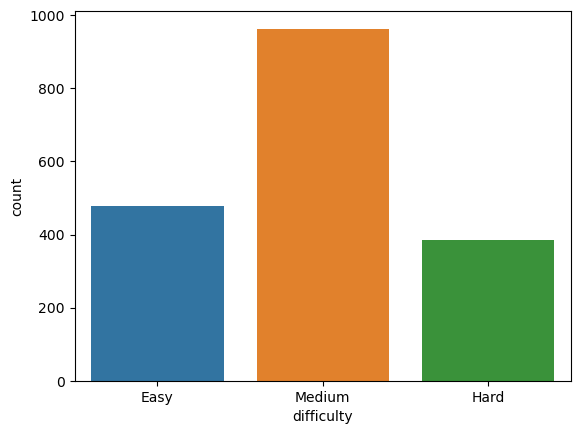

In [18]:

ax = sns.countplot(x=new_df['difficulty'])


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

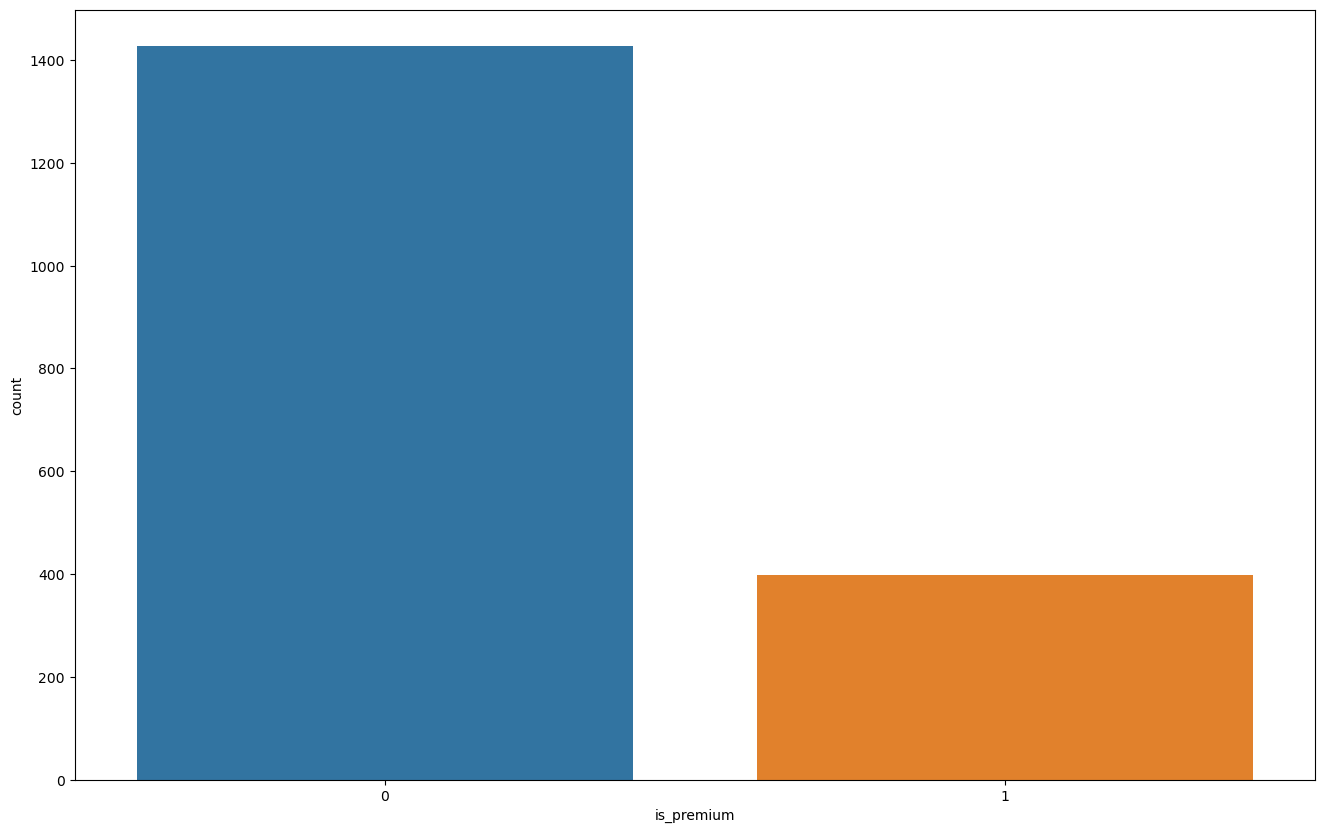

In [19]:
plt.figure(figsize = (16,10))
ax = sns.countplot(x=new_df['is_premium'])
plt.xticks(rotation=0)

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

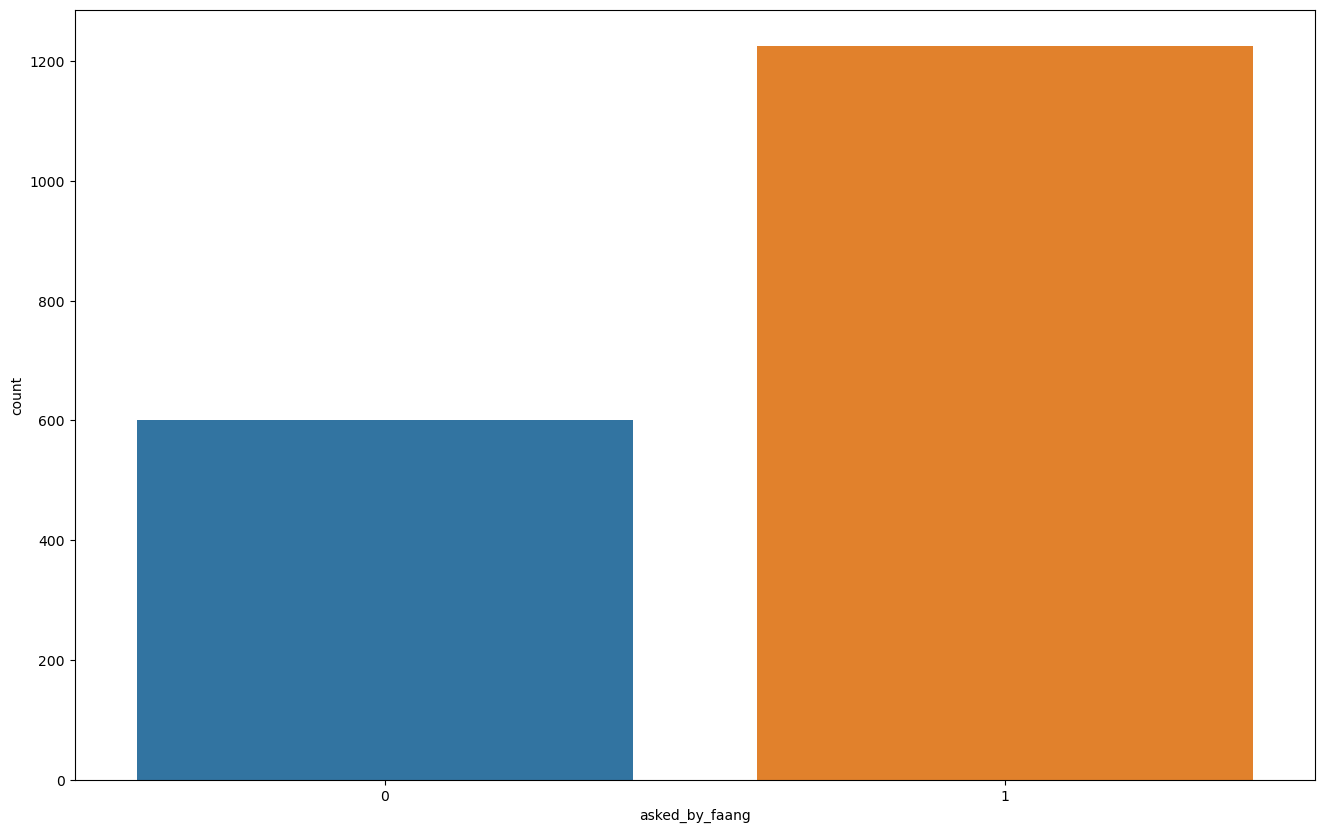

In [20]:
plt.figure(figsize = (16,10))
ax = sns.countplot(x=new_df['asked_by_faang'])
plt.xticks(rotation=0)

In [21]:
new_df

,id,title,is_premium,difficulty,acceptance_rate,frequency,discuss_count,accepted,submissions,likes,dislikes,rating,asked_by_faang
0,1,Two Sum,0,Easy,46.7,100.0,999,41000000,87000000,20217,712,97,1
1,2,Add Two Numbers,0,Medium,35.7,93.1,999,19000000,52000000,11350,2704,81,1
2,3,Longest Substring Without Repeating Characters,0,Medium,31.5,90.9,999,21000000,67000000,13810,714,95,1
3,4,Median of Two Sorted Arrays,0,Hard,31.4,86.2,999,9047000,29000000,9665,1486,87,1
4,5,Longest Palindromic Substring,0,Medium,30.6,84.7,999,13000000,41000000,10271,670,94,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,1821,Find Customers With Positive Revenue this Year,1,Easy,88.9,0.0,15,305,343,2,2,50,1
1821,1822,Sign of the Product of an Array,0,Easy,67.8,0.0,104,79000,117000,37,4,90,0
1822,1823,Find the Winner of the Circular Game,0,Medium,71.8,0.0,135,68000,95000,81,4,95,0
1823,1824,Minimum Sideway Jumps,0,Medium,47.2,0.0,134,5000,107000,147,8,95,0


In [22]:
list1=new_df['difficulty'].value_counts()
list1

Medium    963
Easy      477
Hard      385
Name: difficulty, dtype: int64

In [23]:
list2=["Medium","Easy","Hard"]

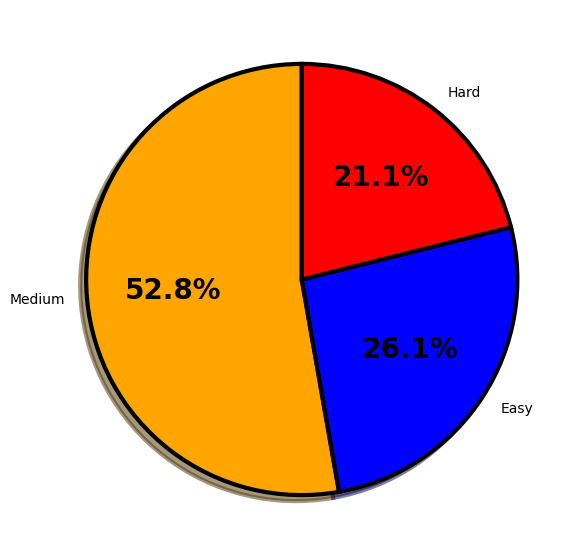

In [24]:
# Creating color parameters
colors = ( "orange", "blue", "red")
 
# Wedge properties
wp = { 'linewidth' : 3, 'edgecolor' : "black" }

def func(pct, allvalues):
    absolute = int(pct / 100.*np.sum(allvalues))
    return "{:.1f}%".format(pct, absolute)
# Creating plot
fig, ax = plt.subplots(figsize =(10, 7))
wedges, texts, autotexts = ax.pie(list1,
                                  autopct = lambda pct: func(pct, list1),
                                  labels = list2,
                                  shadow = True,
                                  colors = colors,
                                  startangle = 90,
                                  wedgeprops = wp,
                                  textprops = dict(color ="black"))
 
 
plt.setp(autotexts, size = 20, weight ="bold")

 
# show plot
plt.show()

In [25]:
new_df

,id,title,is_premium,difficulty,acceptance_rate,frequency,discuss_count,accepted,submissions,likes,dislikes,rating,asked_by_faang
0,1,Two Sum,0,Easy,46.7,100.0,999,41000000,87000000,20217,712,97,1
1,2,Add Two Numbers,0,Medium,35.7,93.1,999,19000000,52000000,11350,2704,81,1
2,3,Longest Substring Without Repeating Characters,0,Medium,31.5,90.9,999,21000000,67000000,13810,714,95,1
3,4,Median of Two Sorted Arrays,0,Hard,31.4,86.2,999,9047000,29000000,9665,1486,87,1
4,5,Longest Palindromic Substring,0,Medium,30.6,84.7,999,13000000,41000000,10271,670,94,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,1821,Find Customers With Positive Revenue this Year,1,Easy,88.9,0.0,15,305,343,2,2,50,1
1821,1822,Sign of the Product of an Array,0,Easy,67.8,0.0,104,79000,117000,37,4,90,0
1822,1823,Find the Winner of the Circular Game,0,Medium,71.8,0.0,135,68000,95000,81,4,95,0
1823,1824,Minimum Sideway Jumps,0,Medium,47.2,0.0,134,5000,107000,147,8,95,0


In [26]:
result1 = new_df.groupby(['difficulty'])['acceptance_rate'].mean()
result1

difficulty
Easy      61.201677
Hard      44.612468
Medium    52.555348
Name: acceptance_rate, dtype: float64

In [27]:
result2 = new_df.groupby(['difficulty'])['frequency'].mean()
result2

difficulty
Easy      16.272537
Hard      23.508831
Medium    22.552856
Name: frequency, dtype: float64

In [28]:
result3 = new_df.groupby(['difficulty'])['rating'].mean()
result3

difficulty
Easy      71.331237
Hard      81.836364
Medium    78.615784
Name: rating, dtype: float64

In [29]:
import plotly.express as px

In [30]:
px.histogram(df,x='difficulty',color='is_premium',nbins=10)

In [31]:
new_df[new_df['difficulty']=='Hard'][['id','title','acceptance_rate']].sort_values('acceptance_rate',ascending=False)[:10]

,id,title,acceptance_rate
1766,1767,Find the Subtasks That Did Not Execute,87.7
1478,1479,Sales by Day of the Week,83.3
979,980,Unique Paths III,77.0
430,431,Encode N-ary Tree to Binary Tree,74.9
488,489,Robot Room Cleaner,72.9
1401,1402,Reducing Dishes,72.1
1062,1063,Number of Valid Subarrays,72.1
1027,1028,Recover a Tree From Preorder Traversal,71.0
1283,1284,Minimum Number of Flips to Convert Binary Matr...,70.1
1254,1255,Maximum Score Words Formed by Letters,70.1


In [32]:
new_df[new_df['difficulty']!='Hard'][['id','title','difficulty','acceptance_rate']].sort_values('acceptance_rate')[:50]

,id,title,difficulty,acceptance_rate
7,8,String to Integer (atoi),Medium,15.7
28,29,Divide Two Integers,Medium,16.9
664,665,Non-decreasing Array,Medium,19.9
219,220,Contains Duplicate III,Medium,21.4
165,166,Fraction to Recurring Decimal,Medium,22.4
287,288,Unique Word Abbreviation,Medium,23.2
443,444,Sequence Reconstruction,Medium,23.7
150,151,Reverse Words in a String,Medium,24.1
193,194,Transpose File,Medium,24.4
1487,1488,Avoid Flood in The City,Medium,24.6


In [33]:
new_df

,id,title,is_premium,difficulty,acceptance_rate,frequency,discuss_count,accepted,submissions,likes,dislikes,rating,asked_by_faang
0,1,Two Sum,0,Easy,46.7,100.0,999,41000000,87000000,20217,712,97,1
1,2,Add Two Numbers,0,Medium,35.7,93.1,999,19000000,52000000,11350,2704,81,1
2,3,Longest Substring Without Repeating Characters,0,Medium,31.5,90.9,999,21000000,67000000,13810,714,95,1
3,4,Median of Two Sorted Arrays,0,Hard,31.4,86.2,999,9047000,29000000,9665,1486,87,1
4,5,Longest Palindromic Substring,0,Medium,30.6,84.7,999,13000000,41000000,10271,670,94,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,1821,Find Customers With Positive Revenue this Year,1,Easy,88.9,0.0,15,305,343,2,2,50,1
1821,1822,Sign of the Product of an Array,0,Easy,67.8,0.0,104,79000,117000,37,4,90,0
1822,1823,Find the Winner of the Circular Game,0,Medium,71.8,0.0,135,68000,95000,81,4,95,0
1823,1824,Minimum Sideway Jumps,0,Medium,47.2,0.0,134,5000,107000,147,8,95,0


In [34]:
px.histogram(df,x='difficulty',color='asked_by_faang',nbins=10)

In [35]:
corr=new_df.corr()

In [36]:
corr

,id,is_premium,acceptance_rate,frequency,discuss_count,accepted,submissions,likes,dislikes,rating,asked_by_faang
id,1.000000,0.081054,0.349228,-0.495780,-0.582344,-0.511419,-0.492719,-0.563142,-0.344787,0.060674,-0.295323
is_premium,0.081054,1.000000,0.243377,-0.205241,-0.363184,-0.187912,-0.175024,-0.260686,-0.147680,-0.043871,-0.039971
acceptance_rate,0.349228,0.243377,1.000000,-0.231853,0.019810,-0.106082,-0.205868,-0.164774,-0.179264,0.102832,-0.089183
frequency,-0.495780,-0.205241,-0.231853,1.000000,0.519824,0.511020,0.499880,0.646910,0.236260,0.136039,0.282584
discuss_count,-0.582344,-0.363184,0.019810,0.519824,1.000000,0.609599,0.554679,0.668338,0.307642,0.145977,0.277767
accepted,-0.511419,-0.187912,-0.106082,0.511020,0.609599,1.000000,0.900831,0.829208,0.311225,0.104490,0.215315
submissions,-0.492719,-0.175024,-0.205868,0.499880,0.554679,0.900831,1.000000,0.785737,0.369670,0.056038,0.208479
likes,-0.563142,-0.260686,-0.164774,0.646910,0.668338,0.829208,0.785737,1.000000,0.179362,0.268897,0.282941
dislikes,-0.344787,-0.147680,-0.179264,0.236260,0.307642,0.311225,0.369670,0.179362,1.000000,-0.516769,0.098759
rating,0.060674,-0.043871,0.102832,0.136039,0.145977,0.104490,0.056038,0.268897,-0.516769,1.000000,0.085150


<AxesSubplot:>

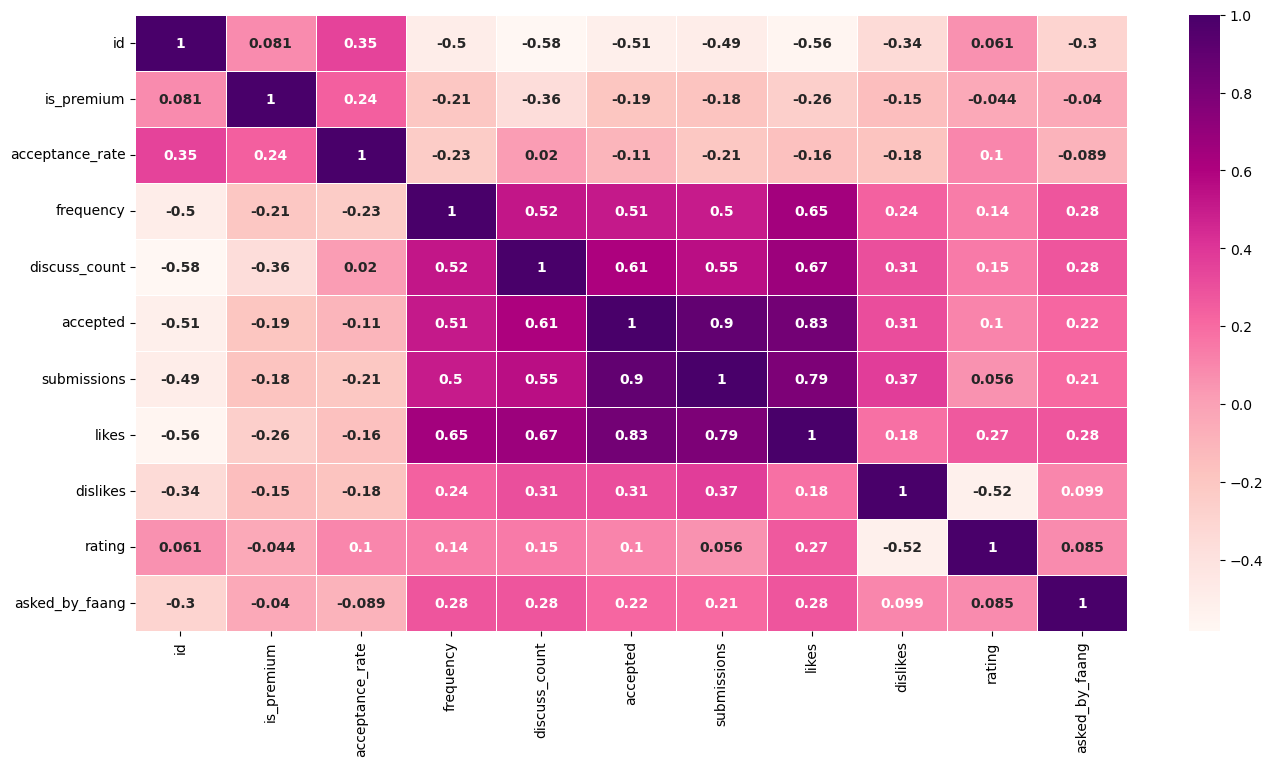

In [37]:
fig=plt.figure(figsize=(16,8))
sns.heatmap(corr, annot=True, annot_kws={'weight':'bold'},linewidths=.5, cmap='RdPu')

In [38]:
df

,id,title,description,is_premium,difficulty,solution_link,acceptance_rate,frequency,url,discuss_count,accepted,submissions,companies,related_topics,likes,dislikes,rating,asked_by_faang,similar_questions
0,1,Two Sum,Given an array of integers `nums` and an integ...,0,Easy,/articles/two-sum,46.7,100.0,https://leetcode.com/problems/two-sum,999,4.1M,8.7M,"Amazon,Google,Apple,Adobe,Microsoft,Bloomberg,...","Array,Hash Table",20217,712,97,1,"[3Sum, /problems/3sum/, Medium], [4Sum, /probl..."
1,2,Add Two Numbers,You are given two non-empty linked lists repre...,0,Medium,/articles/add-two-numbers,35.7,93.1,https://leetcode.com/problems/add-two-numbers,999,1.9M,5.2M,"Bloomberg,Microsoft,Amazon,Google,Facebook,App...","Linked List,Math,Recursion",11350,2704,81,1,"[Multiply Strings, /problems/multiply-strings/..."
2,3,Longest Substring Without Repeating Characters,"Given a string `s`, find the length of the lon...",0,Medium,/articles/longest-substring-without-repeating-...,31.5,90.9,https://leetcode.com/problems/longest-substrin...,999,2.1M,6.7M,"Amazon,Bloomberg,Microsoft,Facebook,Apple,Adob...","Hash Table,Two Pointers,String,Sliding Window",13810,714,95,1,[Longest Substring with At Most Two Distinct C...
3,4,Median of Two Sorted Arrays,Given two sorted arrays `nums1` and `nums2` of...,0,Hard,/articles/median-of-two-sorted-arrays,31.4,86.2,https://leetcode.com/problems/median-of-two-so...,999,904.7K,2.9M,"Amazon,Goldman Sachs,Facebook,Microsoft,Apple,...","Array,Binary Search,Divide and Conquer",9665,1486,87,1,NaN
4,5,Longest Palindromic Substring,"Given a string `s`, return the longest palindr...",0,Medium,/articles/longest-palindromic-substring,30.6,84.7,https://leetcode.com/problems/longest-palindro...,999,1.3M,4.1M,"Amazon,Microsoft,Wayfair,Facebook,Adobe,eBay,G...","String,Dynamic Programming",10271,670,94,1,"[Shortest Palindrome, /problems/shortest-palin..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820,1821,Find Customers With Positive Revenue this Year,SQL Schema,1,Easy,NaN,88.9,0.0,https://leetcode.com/problems/find-customers-w...,15,305,343,Google,NaN,2,2,50,1,NaN
1821,1822,Sign of the Product of an Array,There is a function `signFunc(x)` that returns...,0,Easy,NaN,67.8,0.0,https://leetcode.com/problems/sign-of-the-prod...,104,7.9K,11.7K,Microsoft,Math,37,4,90,0,NaN
1822,1823,Find the Winner of the Circular Game,There are `n` friends that are playing a game....,0,Medium,NaN,71.8,0.0,https://leetcode.com/problems/find-the-winner-...,135,6.8K,9.5K,Bloomberg,Array,81,4,95,0,NaN
1823,1824,Minimum Sideway Jumps,There is a 3 lane road of length `n` that cons...,0,Medium,NaN,47.2,0.0,https://leetcode.com/problems/minimum-sideway-...,134,5K,10.7K,Pony.ai,"Dynamic Programming,Breadth-first Search",147,8,95,0,"[Frog Jump, /problems/frog-jump/, Hard]"
